# 추천 시스템 _사전과제
-----
## 1. 추천 시스템이란?
-----
* 추천 시스템: 사용자의 정보 데이터를 분석하여 취향에 맞는 아이템을 추천하는 알고리즘 

### (1) 사용되는 데이터
1. 명시적 데이터
   * 사용자가 선호도를 직접적으로 입력한 데이터. (평점, 좋아요, 투표 등)
   * 당시 사용자의 취향이 반영됨, but 데이터 자체를 얻기 힘들다
2. 암시적 데이터
   * 사용자의 행동을 기반으로 수집하여 선호도가 간접적으로 표현된 데이터 (조회수, 영상시청 기간, 구매 기록 등)
   * 데이터를 얻기 쉬움, but 취향을 직접적으로 알 수는 없음
         
### (2) 추천 시스템의 분류

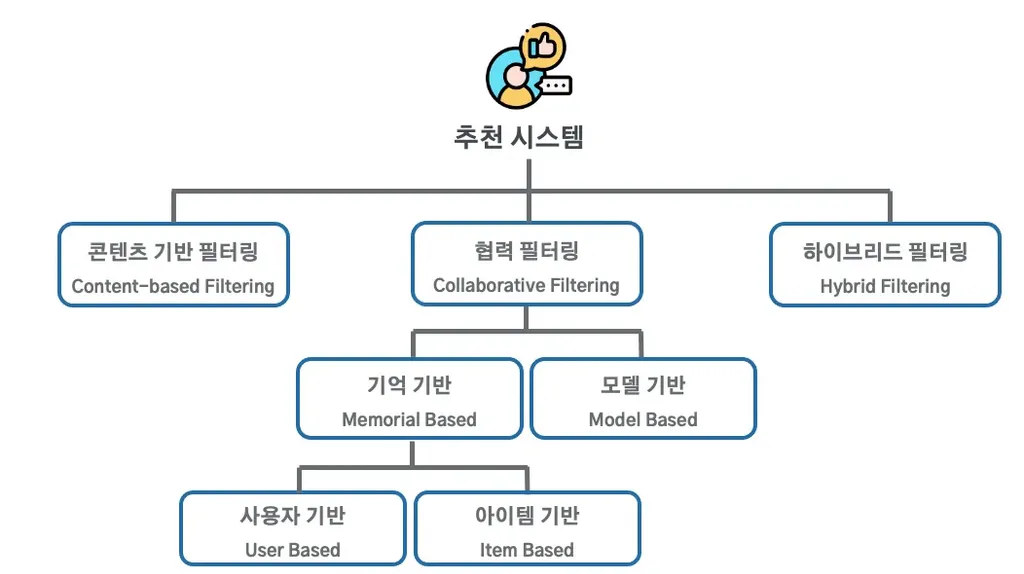

1. 내용 기반 필터링 (Content-based filtering)
   * 콘텐츠의 유사도를 기반으로 사용자에게 추천하는 방법

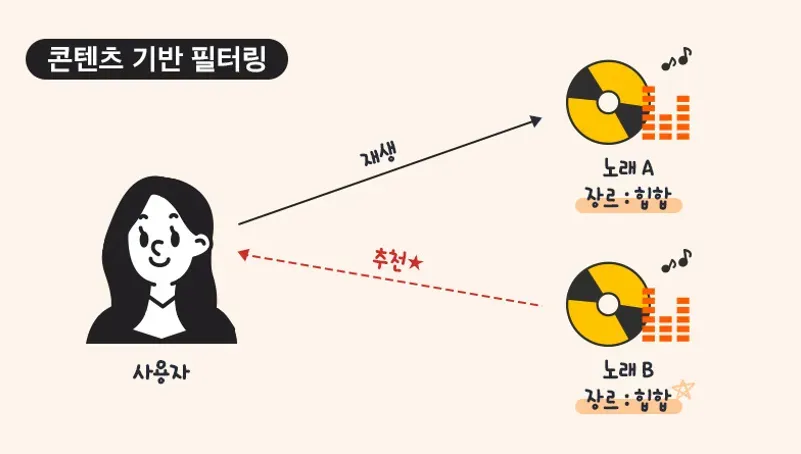

2. 협업 필터링 (Collaborative Filtering)
   * 다수의 사용자로부터 얻은 선호도 정보를 기반으로 사용자에게 추천하는 방법
   * 비슷한 관심사를 가지고 있는 두 사람이 있을 때, 한 사용자의 데이터를 바탕으로 다른 사용자에게 추천해주는 방식.          
  
        (1) 사용자 기반(User-Based Filtering): 특정 사용자와 유사한 취향의 사용자가 선호한 아이템 추천.            
          + ex. A와 B 비슷한 음악 들음 -> A가 듣는거 B에게도 추천함           
            
        (2) 아이템 기반: 사용자가 선호한 아이템과 유사한 아이템 추천           
          + ex. A가 백예린 들음 -> 백예린 듣는 다른 사람들은 보통 발룬티어스도 들음 -> 백예린이랑 발룬티어스는 유사한 아이템이구나 판단 -> A에게 발룬티어스 추천

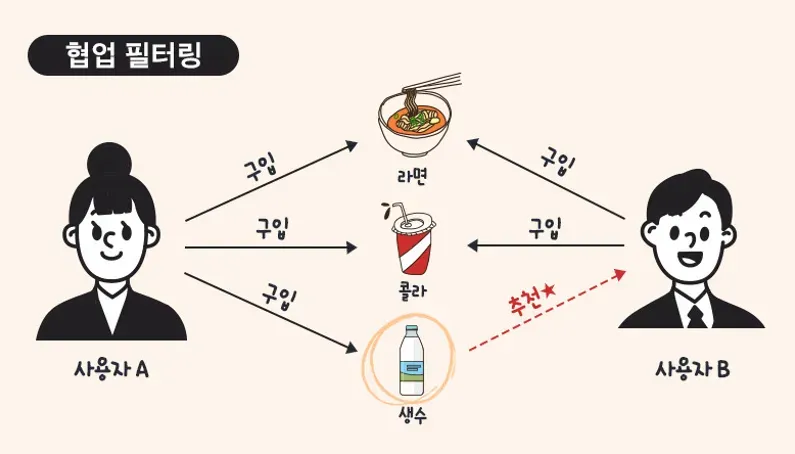

3. 하이브리드 필터링 (Hybid Filtering)
   * 2가지 이상의 추천 시스템 알고리즘 조합하여 각각의 단점 보완함.

## 2. 내용 기반 필터링
-----
### (1) 사용자 프로필
* 추천시스템에 사용되는 데이터
  1. 직접 지정형: 사용자가 명시적으로 지정
  2. 간접 지정형: 사용자 과거 행동 이력 기반으로 작성
* 사용자 프로필 획득 방식
1. 특성 가중치는 사용자가 가지고 있는 아이템 특성 중 가중치의 평균값
2. 사용자 기호는 따로 파악
3. 아이템에 대한 기존 유저의 평가 바탕으로 분류 문제 해결         
  -> 명시적 + 암묵적 혼합하여 사용

### (2) 유사도
1. 영상, 이미지, 텍스트 형태의 아이템 정보 데이터를 **벡터화** 하여 아이템 벡터 간 유사도 측정 -> 측정 유사도 바탕으로 고객 선호 아이템과 비교         
   + 인풋 데이터 만들기: 아이템 정보를 피처 추출해 데이터 테이블로 만들고 원-핫 인코딩
   + 유저와 아이템을 동일한 기준의 피처로 표현해 벡터 계산 가능하게 함
2. 아이템 벡터간의 유사도를 측정한다; 유저 벡터와 아이템 벡터를 내적해 값이 큰 것이 유사도가 높은 것.
3. 이를 바탕으로 고객이 선호하는 아이템과 비교하여 유사도가 높은 아이템을 선별

#### TF-IDF (Term Frequency- Inverse Document Frequency)
* TF(단어 빈도; 특정 문서에 특정 단어의 출현 빈도)와 IDF(역문서 빈도;전체 문서에 특정 단어의 출현 빈도) 통해서 **다른 문서에는 등장하지 않지만 특정 문서에서만 자주 등장하는 단어** 찾아서 **문서 내 단어의 가중치** 계산하는 방법
* $TF(d,t)$ : 특정 문서 d 에서 특정 단어 t 의 등장 횟수
* $DF(t)$ : 특정 단어 t가 등장한 문서의 수
* $IDF(d,t)=\log{\frac{n}{1+df(t)}}$
* $TF-IDF=TF(d,t)*IDF(d,t)$
* 즉 특정 단어가 특정 문서에만 들어있을 수록 IDF 증가 -> 더 중요한 단어로 인식.

#### 내용 기반 필터링 장단점
* 장점
  + 아이템에 대한 콜드 스타트 문제(정보 수집이 충분하지 않아 추천 불가능) 해결 가능
  + 아이템의 피처를 통해 추천하므로 이유 설명 가능
* 단점
  + 아이템의 정확한 피처 추출 못하면 정확도 감소
  + 기존 아이템과 유사한 아이템 위주로만 추천해, 새로운 장르의 아이템 추천 어려움

## 3. 협업 필터링; 자세히 알아보기
-----
* 가정: 과거 비슷한 선호도를 가진 사용자들은 앞으로도 비슷한 선호도 가질 가능성이 높다

### (1) 메모리 기반 협업 필터링 (Memory-Based Collaborative Filtering)
* 이웃 기반 협업 필터링.
* 사용자 또는 아이템 간 유사도를 기반으로 한다
* 두 가지 형태의 접근법 존재
  + 사용자 기반(User-Based, UBCF)
    - 유저 간의 유사도가 높을수록 높은 가중치
    - 아이템 수 > 사용자 수 일때 적합
    - 아이템이 수시로 바뀌는 경우 적합
    - IBCF보다 추천 범위 다양
  + 아이템 기반(Item-Based; IBCF)
    - 아이템간의 유사도가 높을수록 높은 가중치
    - 사용자 수 > 아이템 수 일때 적합
    - 아이템 리스트 변화가 적고 고정적인 경우 적합
    - 계산이 빨라서 사용자 유입이 많은 환경에서 유리, but 참신성 부족          

* 정리
  + 새로운 추천이 필요한 플랫폼 -> User-based
  + 사용자에게 아이템이 치중된 플랫폼 -> Item-based
* 한계
  + 희소 행렬 문제: 유저-아이템 행렬 대부분 원소 비어있다
  + 확장성 문제: 아이템, 유자가 계속 늘어날 경우 확장성 떨어진다
  + 콜드스타트 문제: 기존 데이터가 없는 경우 추천 불가  


                
### 모델 기반 협업 필터링 (Model-Based Collaborative Filtering)
* 데이터로부터 패턴을 학습한 모델 만들어 평점 예측. 즉 관측된 평점 데이터를 학습하여 관측되지 않은 평점을 예측하는 방식
* 잠재요인 (Latent Factor): 사용자와 아이템 간의 관계를 설명해주는, 눈에 보이지 않는 숨겨진 요인.

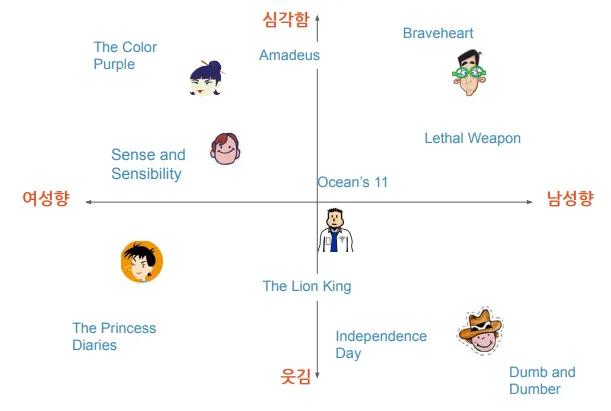

> Factor Model. 아이템, 유저의 구분 없이 동일한 차원의 벡터 공간에 좌표로 표현
> * 유저와 아이템 서로의 거리나 각도로 유사도 파악 가능

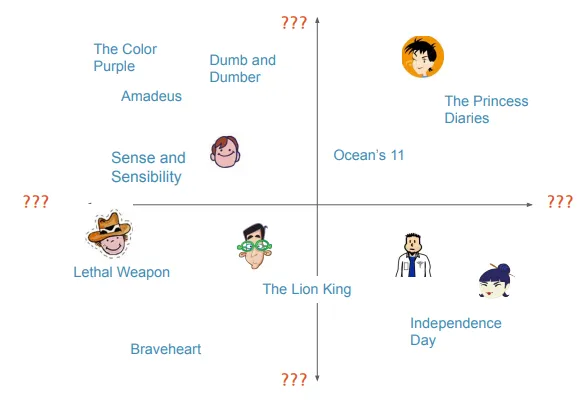

> Latent Factor Model. 잠재적 특성을 파악하기 때문에 축이 무엇인지, 몇개인지도 모름. 각 벡터를 명시적으로 이해는 불가하지만, 각 좌표벡터간의 거리, 각도는 계산 가능해서 유사도 파악 가능.

* 행렬 분해(Matrix Fatorization): User-Item Matrix를 분해하여 유저의 잠재요인과 아이템의 잠재요인의 내적으로 설명 -> 평점 예측 가능

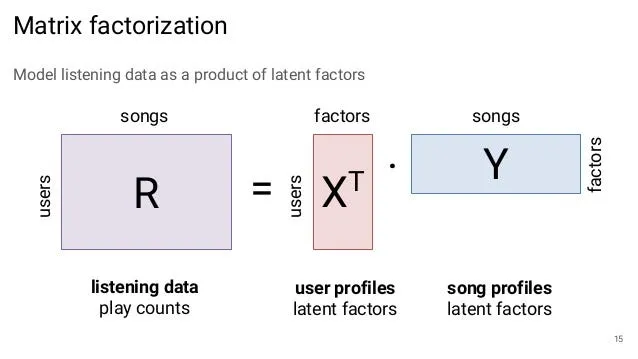

#### 행렬 분해 방식
1. SVD, 특이값 분해
   * 정방행렬이 아니어도 $A={U}\sum{V^T}$ 로 분해할 수 있는 방법
   * A=사용자-아이템 평점 행렬
   * U=사용자 관련 정보 직교행렬
   * $\sum$=대각행렬(주대각성분이 A의 특이값 내림차순이다)
        + 특이값의 의미: 각 특이값은 해당 잠재요인이 원래 행렬 A에서 얼마나 많은 정보량 또는 중요도를 설명하는지를 나타냄
  * 모든 특이값과 고유벡터를 사용하는 Full SVD(완전 특이값 분해)와 상위 k개만 사용하는 Truncated SVD(절단 특이값 분해)로 나눌 수 있다.
 * Full SVD는 계산 비용이 크고 노이즈를 포함하므로, 행렬을 k차원으로 근사한 Truncated sVD를 사용하는 경우가 많다.

2. SGD (Stochastic Gradiendt Descent): SVD 행렬의 한계때문에 고안됨
* 목표: 목적함수
* 목적함수: 관측된 평점과 예측 평점 사이의 오차를 최소화 하는 것이 목적. 오차의 제곱합을 최소화 & 과적합 방지 위한 정규화 항 추가함

3. NMF (Non-Negatice Matrix Factorization)
* 정의: P와$Q^T$의 모든 원소가 0 이상이어야 한다는 제약 조건을 추가한 행렬 분해 기법. 대부분의 현실데이터가 음수일 수 없다는 점 이용,
* 장점: 직관적 의미 부여 가능 (각 잠재요인 값이 유저의 선호도 or 아이템의 특성 강도를 나타낸다고 직관적으로 해석할 수 있음)

4. PMF (Probabilistic Factorization)
* 목표: 누가 무엇을 좋아할지 예측
* 확률적 모델로 접근하여, 예를 들어 평점이 4.3, 표준편차 0.2 정도 될것 같다는 식으로 불확실성 포함함
* 베이지안 추론 기밥과 결합되어 더 정교한 추천 모델이 됨

## 2. 딥러닝 기반 추천 시스템
---------

### 1. VAE 기반 협업 필터링 (Variational Autoencoder CF)
* 정의: 사용자의 아이템 상호작용 벡터를 입력으로 받아 잠재 공간에서 재구성하도록 VAE를 학습하는 방식.
* 장점: 기존 MF 처럼 단일 포인트 벡터가 아닌 확률적 잠재 분포라서 불확실성을 반영 가능, 희소한 상호작용 데이터에서도 좋음

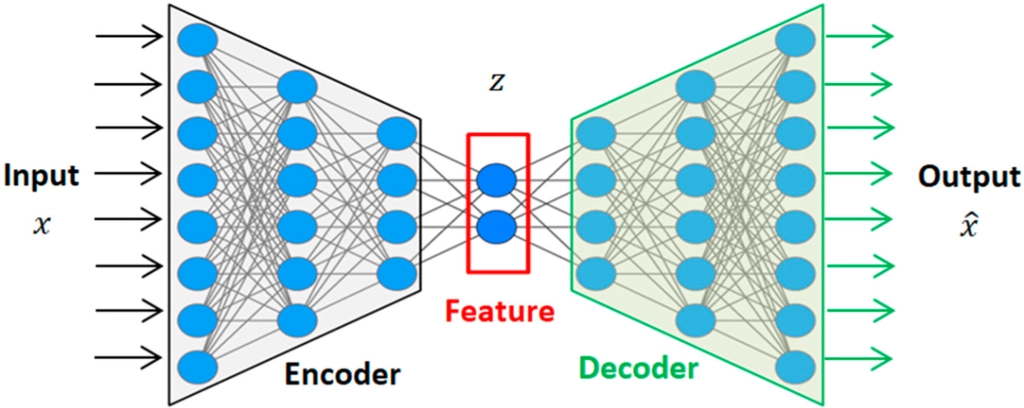

> * 구조
> * 인코더: 사용자 이력 잠재변수 z 분포로 매핑
> * 디코더: z로부터 아이템 분포 복원

1. MF의 한계와 딥러닝의 등장
   * MF가 희소성과 확장성 문제 해결했으나, 근본적으로 내적으로만 이루어지고 단일 벡터값을 사용하므로 모델링의 한계가 있다
   * 따라서 비선형 활성화 함수 가진 신경망을 사용할 수있고, 확률 분포로 불확실성을 반영할 수 있는 딥러닝이 고안됨

2. 왜 AE가 아닌 VAE인가
* AE는 단일 값을 추정하므로 데이터가 부족하면 틀리기 쉬움(불안정)
* VAE는 분포를 추정하므로 불확실성(오차 범위)을 모델링에 포함시켜 안정성을 줌

3. VAE 기반 CF 작동구조
* 입력: 사용자 아이템 상호작용 벡터
* 인코더: 잠재변수 z분포로 매핑
* 잠재벡터: 샘플링된 최종 취향 벡터
* 디코더: z로부터 아이템 분포 복원

4. VAE: 목적함수와 KL Divergence

> 1. 재구성 오차 최소화 항: 디코더가 잠재벡터 z 사용해 원래 입력 x와 최대한 비슷하게 복원하도록 만듦
> 2. KL Divergence 항: 인코더가 출력하는 잠재분포 q(z|x)가 사전분포 p(z)와 유사하도록 강제함 -> 모델이 특정 데이터에 과적합하는 것을 방지해 잠재공간 넓고 부드럽게 만듦

* KL Divergence의 역할: 희소한 데이터여도(데이터가 부족한 유저) 유저 벡터들이 **표준 정규 분포 주변**에 유지하도록 만든 잠재 벡터 공간의 분포 덕분에, 자연스럽게 정보를 **보간**할 수 있음 -> VAE가 희소 데이터에 강한 이유!

* VAE-CF의 주요 장점 정리
  1. 확률적 잠재 분포 모델링 (불확실성 반영)
  2. 희소한 상호작용 데이터에서도 강건함 (보간 능력 뛰어남)
  3. 비선형성 학습 (신경망 구조여서) 

###  GNN 기반 사용자 선호 예측 (Graphic Neural Network)
(1) GNN: 사용자-아이템 상호작용을 서로가 연결된 거대한 관계망을 형성한다고 봄 -> 그래프
   * 그래프: 노드(개체)와 엣지(개체간 관계나 상호작용)로 구성한 자료구조
    + 관계, 상호작용 같은 추상적 개념을 명시적 데이터로 구조화 가능(노드-엣지-노드)
    + non-euclidean space 표현, 학습 가능 -> 복잡하고 불규칙한 데이터 모델링

(2) GNN의 작동 구조
* 핵심 아이디어: 내 이웃 노드(나와 비슷한 사용자, 내가 본 아이템)의 정보를 나에게 전달, 요약 (message passing)

(3) GNN 프로세스

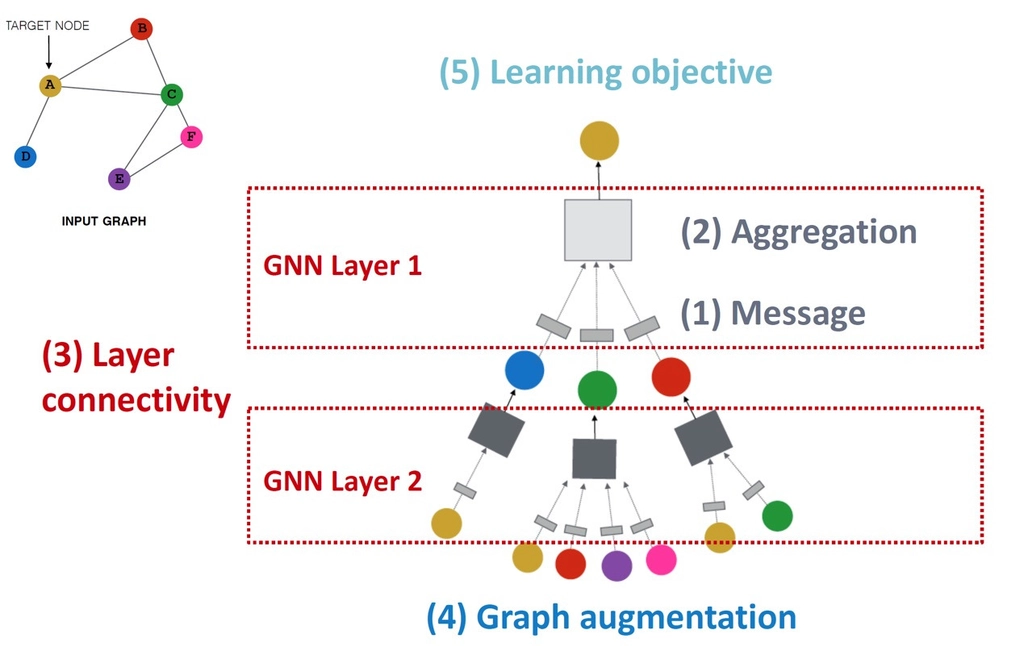

1. 그래프 구조 생성
   * 노드와 엣지를 정의한 후, 각각의 피처를 담아 표현함
  


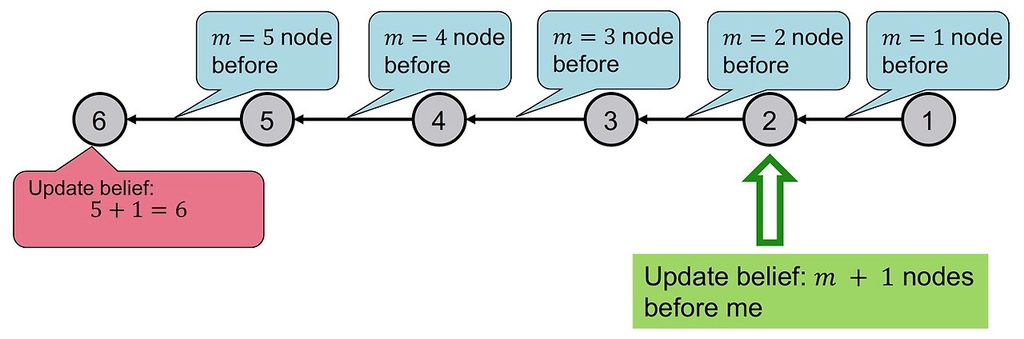

2. 메시지 패싱
   * 메시지: 각 노드가 이웃에게 보내는 자신의 정보(임베딩)
   * 노드간 정보를 전달하고 상호작용하는 방법
   * 하나의 GNN레이어에서 '메세지 생성-집계-갱신'의 세 단계 이루어짐
   * 레이어 개수만큼 위 과정 반복

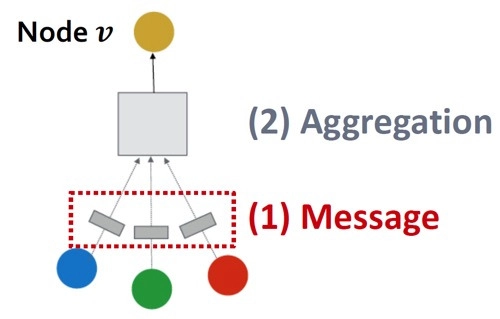

3. 메시지 생성: v의 이웃에게 전달할 메시지 생성 (메시지 함수)

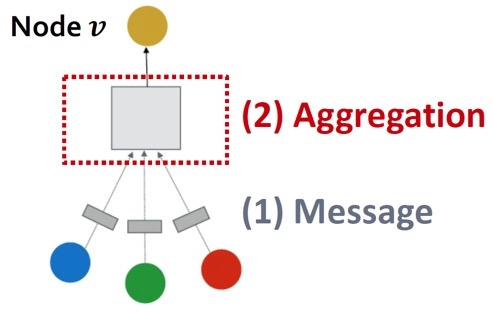

4. 집계: 메시지 생성 이후 여러 이웃 노드에서 받은 메시지 하나의 벡터로 통합

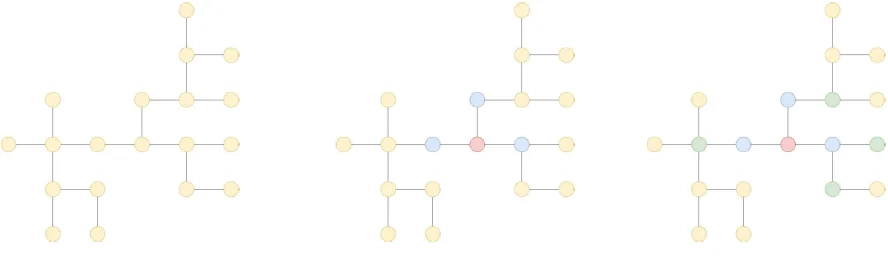

5. 갱신(update): v노드의 원래 임베딩과 집계된 이웃 임베딩을 결합해 새로운 임베딩 계산

(4) Light GCN (Light Graph Convolution Networks)
* GCN: GNN의 아키텍처 중 하나로, 그래프 위에서 합성곱(convolution)연산을 수행. 
* Light GCN: GCN에서 2가지 요소를 제거해 복잡한 연산이 순수한 관계 정보 왜곡하는 것을 방지
  1. 특징 변환 제거: 레이어마다 복잡했던 학습 파라미터 삭제
  2. 비선형 활성화 함수 제거: relu같은 활성화함수 사용하지 않고 이웃 정보 합침 -> 정규화도니 합 혹은 평균을 사용함        
=> 즉 light GCN은 오직 **정규화된 이웃 임베딩의 합**만으로 구성되어 매우 가볍고 효율이 좋다

(5) GNN 활용 사례: 핀터레스트, traffic; 한 장소에서 다른 장소까지 얼마나 걸리는지 등

(6) GNN 장단점
* 장점
  1. 고차원 협업 시그널 포착: 나와 취향이 비슷한 사용자들, 내가 본 아이템의 연관 아이템 정보를 직접 반복해서 반영 가능
  2. 정형화되지 않은 데이터 학습 가능: 관계를 학습하므로
  3. cold start 문제 완화 가능: 이웃 관계 활용해 신규 사용자의 임베딩 생성
* 단점
  1. 과평탄화(over-smothing)문제: 모든 노드의 임베딩이 같은 값으로 수렴하는 현상. 메시지 전달을 반복해 레이어가 많아질수록 노드간 임베딩이 비슷해질 수 있다.
  2. 과압축 문제: GNN의 층이 깊어질수록 집계하는 이웃의 범위가 기하급수적으로 커지는데, 고정된 크기의 벡터 하나에 모두 압축하려면 정보 손실됨
  3. 계산 복잡도 증가
  4. 해석 어려움: 순서 반영이 안됨

#### 2.3 Transformer 기반 추천 시스템
: 순차적 정보를 다루는데 한계가 있는 CF와 GNN 모델의 대안으로 고안됨. 사용자의 행동 시퀀스를 언어처럼 이해하고 다음 행동을 예측할 수 있기 때문

* 시간 순서나 거리에 얽매이지 않고, 전체 시퀀스 내에서 현재 의도와 가장 관련성이 높은 핵심 문맥을 주목해 예측함.
* 핵심: Self-Attention
  + 시퀀스 내 모든 아이템 간의 관계를 거리에 상관없이 동시 계산
  + Attention Score 계산 -> softmax -> 가중치로 변환 -> 각 아이템의 value에 곱하여 모두 더함 (가중 평균) => 문맥 반영한 벡터 생성됨

* Transformer 기반 주요 추천 시스템 모델
   1. SASRec (Self-Attention Sequential Recommendation)
      * 방식: 단방향 어텐션(과거의 아이템들만 참조)
      * 목표: 다음 아이템 예측
      * 문제점: 계산량 많고 단방향성 => BERT4rec 등장
    2. BERT4Rec (BERT for Recommendation)
   * 방식: 양방향 어텐션 (BERT)과 유사
   * 목표: 시퀀스 내 가려진 아이템 예측 ([MASK])
   * 특징: 아이템의 양방향 문맥 (과거와 미래)모두 고려, 시퀀스 전체의 선호도 파악하는데 초점이 맞춰짐

## 4. 오늘날의 추천 시스템
(1) LLM
* 관점의 전환: 추천을 랭킹 문제가 아닌 언어 문제로 푼다 (의미 기반 추천)
* 새로운 가능성: LLM은 문맥을 이해할 수 있으므로 평점이 없는 새로운 아이템도 빠르게 추천 대상에 포함시킬 수 있다. -> cold start 문제 완화
* 모델

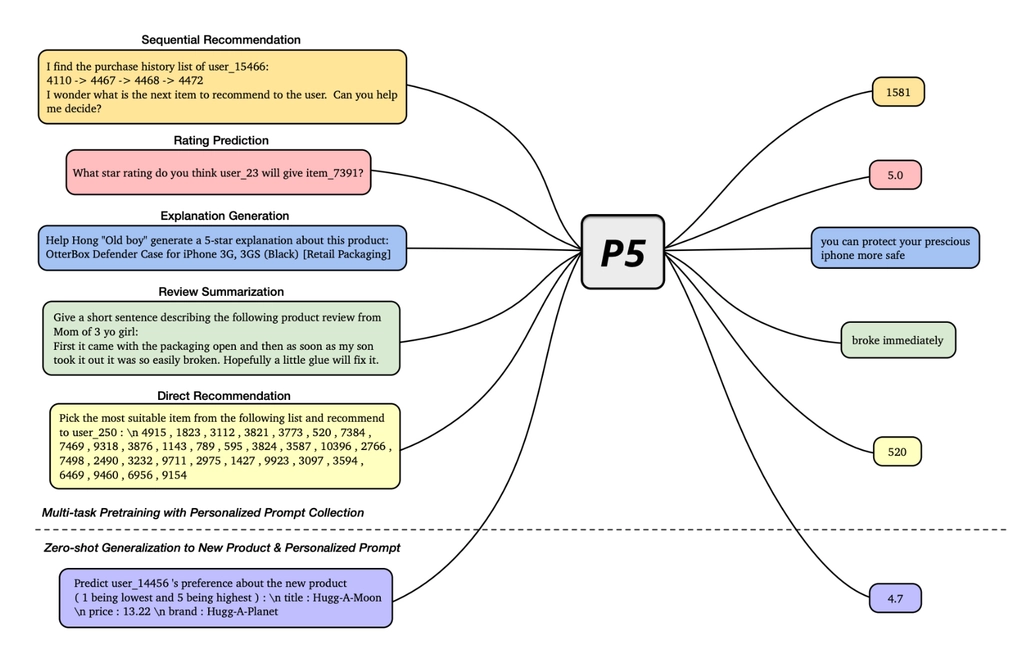

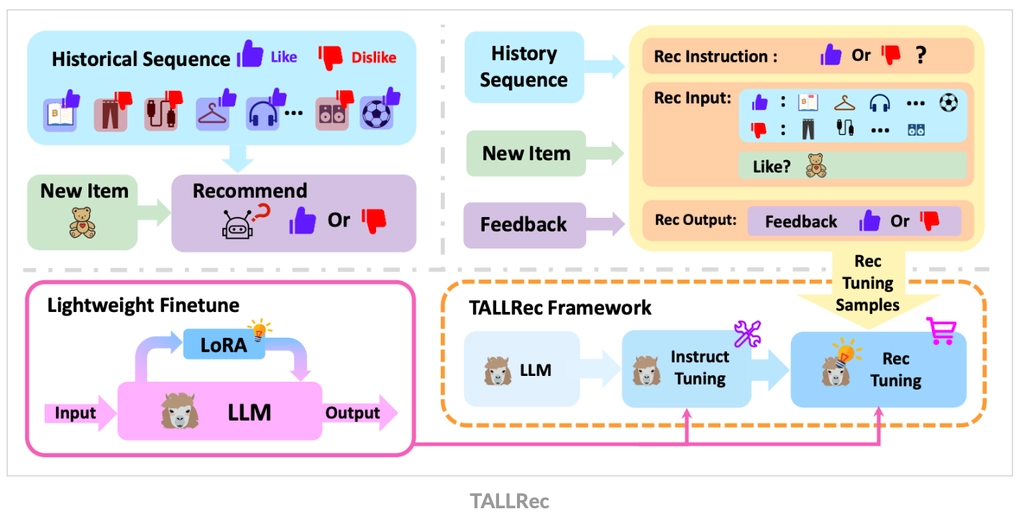

(2) 인기 편향과 XAI 문제
* 인기편향: 비인기, 신규 아이템 노출 기회가 적어짐
* 설명가능성: 왜 추천했는지 설명할 수 있어야함

(3) 컴퓨팅 자본, 콜드 스타트 문제 고려한 추천시스템 도입
* 선형 기반 추천시스템, 딥러닝 기반 추천시스템과 병행 